In [1]:
import scanpy as sc
import anndata
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import scvi
import seaborn as sb

## GSE115978

In [2]:
adata_final =sc.read_h5ad("./output_0531/GSE115978/GSE115978_raw.h5ad")

In [4]:
adata_final.obs['samples'].value_counts()

samples
Mel79       894
Mel75       506
Mel80       431
Mel89       391
Mel88       352
Mel102      322
Mel103      317
Mel94       311
Mel98       270
Mel110      258
Mel194      249
Mel105      234
Mel60       226
Mel81       205
Mel106      190
Mel72       181
Mel129pa    179
Mel84       159
Mel478      154
Mel74       147
Mel53       143
Mel58       142
Mel78       124
Mel112      113
Mel121_1    105
Mel126       95
Mel128       89
Mel71        89
Mel82        84
Mel116       84
Mel04_3      78
Mel129pb     64
Name: count, dtype: int64

In [5]:
adata_final

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'samples', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location'

In [6]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/tmp/ipykernel_4091514/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [7]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("./output_0531/GSE115978/GSE115978_raw.h5ad")
samples = sce$samples
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce, samples=samples)
sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="./output_0531/GSE115978/GSE115978_postR.h5ad")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

/usr/bin/bash: /home/lixiangyu/anaconda3/lib/libtinfo.so.6: no version information available (required by /usr/bin/bash)
/usr/bin/bash: /home/lixiangyu/anaconda3/lib/libtinfo.so.6: no version information available (required by /usr/bin/bash)
/usr/bin/bash: /home/lixiangyu/anaconda3/lib/libtinfo.so.6: no version information available (required by /usr/bin/bash)
/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [12]:
adata_final =sc.read_h5ad("./output_0531/GSE115978/GSE115978_postR.h5ad")

In [13]:
adata_final.var['mt'] = adata_final.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata_final, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
# pp-smart-seq2---现在已经是质控后的
# print('Number of cells before gene filter: {:d}'.format(adata_final.n_obs))
# adata_final = adata_final[adata_final.obs["no_of_genes"] >= 1700].copy()
# # sc.pp.filter_cells(adata_final, max_genes=4000) # acc to author
# # sc.pp.filter_genes(adata_final, min_cells=3) #acc to author

# # print('Number of cells before counts filter: {:d}'.format(adata_final.n_obs))

# # # sc.pp.filter_cells(adata_final, max_counts = 20000) #acc to author


# # print('Number of cells beforeMT filter: {:d}'.format(adata_final.n_obs))

# # adata_final = adata_final[adata_final.obs['pct_counts_mt'] < 10] #acc to author
# # print('Number of cells after MT filter: {:d}'.format(adata_final.n_obs))
# print('Number of cells before gene filter: {:d}'.format(adata_final.n_obs))

# gene_mean = np.asarray(adata_final.X.mean(axis=0)).ravel()
# adata_final = adata_final[:, gene_mean >= 4].copy()
# print('Number of cells after gene filter: {:d}'.format(adata_final.n_obs))


Number of cells before gene filter: 7186
Number of cells before gene filter: 7186
Number of cells after gene filter: 7186


In [14]:
##保留原始计数
adata_final.layers["uncorrected_counts"] = adata_final.X.copy()
adata_final.layers["raw_decontXcounts"] = adata_final.layers["decontXcounts"].copy()
adata_final.X = np.around(adata_final.layers["raw_decontXcounts"].copy()).astype(int)
del adata_final.layers["decontXcounts"]
adata_final

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'samples', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UMAP', 'decontX_Mel53_UMAP', 'decontX_Mel58_UMA

In [15]:
adata_final

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'samples', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UMAP', 'decontX_Mel53_UMAP', 'decontX_Mel58_UMA

In [16]:
adata_final.obs = adata_final.obs.rename(columns={"samples": "sample"})
adata_final.obs['sample'].value_counts()

sample
Mel79       894
Mel75       506
Mel80       431
Mel89       391
Mel88       352
Mel102      322
Mel103      317
Mel94       311
Mel98       270
Mel110      258
Mel194      249
Mel105      234
Mel60       226
Mel81       205
Mel106      190
Mel72       181
Mel129pa    179
Mel84       159
Mel478      154
Mel74       147
Mel53       143
Mel58       142
Mel78       124
Mel112      113
Mel121_1    105
Mel126       95
Mel71        89
Mel128       89
Mel116       84
Mel82        84
Mel04_3      78
Mel129pb     64
Name: count, dtype: int64

In [17]:
adata_final.write("./output_0531/GSE115978/GSE115978_postQC-R.h5ad")
adata_final

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UMAP', 'decontX_Mel53_UMAP', 'decontX_Mel58_UMAP

In [18]:
adata_final.var

,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
C9orf152,False,53,0.084470,99.262455,607.0
RPS11,False,6955,365.242833,3.214584,2624635.0
ELMO2,False,2099,38.513777,70.790426,276760.0
CREB3L1,False,71,0.433899,99.011968,3118.0
PNMA1,False,1381,19.567632,80.782076,140613.0
...,...,...,...,...,...
PIK3IP1,False,3039,127.933203,57.709435,919328.0
SNRPD2,False,4668,81.072502,35.040356,582587.0
SLC39A6,False,2158,30.935013,69.969385,222299.0
CTSC,False,6896,162.513638,4.035625,1167823.0


# Prepare query data

In [19]:
adata_final = sc.read_h5ad("./output_0531/GSE115978/GSE115978_postQC-R.h5ad")
adata_final

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UMAP', 'decontX_Mel53_UMAP', 'decontX_Mel58_UMAP

In [20]:
ensembl_id_df = pd.read_csv("/home/lixiangyu/zr/Annotate/gene_names_to_ensembl_ALLFOUND_allfernandez_no6_withallslysz.csv")
gene_to_ensembl = dict(zip(ensembl_id_df['gene_name'], ensembl_id_df['ensembl_id']))
# Map the variable names in AnnData
adata_final.var['original_gene_names'] = adata_final.var_names
adata_final.var_names = [gene_to_ensembl[gene] if gene in gene_to_ensembl else gene for gene in adata_final.var_names]

In [21]:
import numpy as np
from scipy import sparse

X = adata_final.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = X.ravel()

print("min:", vals.min())
print("max:", vals.max())
print("mean:", vals.mean())
print("has decimals:", np.any(vals[:10000] % 1 != 0))

min: 0
max: 1296815
mean: 99.4631145646608
has decimals: False


In [22]:
non_ENSG_vars = adata_final.var_names[~adata_final.var_names.str.startswith('ENSG')]

In [23]:
adata_final.var

,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,original_gene_names
ENSG00000188959,False,53,0.084470,99.262455,607.0,C9orf152
ENSG00000142534,False,6955,365.242833,3.214584,2624635.0,RPS11
ENSG00000062598,False,2099,38.513777,70.790426,276760.0,ELMO2
ENSG00000157613,False,71,0.433899,99.011968,3118.0,CREB3L1
ENSG00000176903,False,1381,19.567632,80.782076,140613.0,PNMA1
...,...,...,...,...,...,...
ENSG00000100100,False,3039,127.933203,57.709435,919328.0,PIK3IP1
ENSG00000125743,False,4668,81.072502,35.040356,582587.0,SNRPD2
ENSG00000141424,False,2158,30.935013,69.969385,222299.0,SLC39A6
ENSG00000109861,False,6896,162.513638,4.035625,1167823.0,CTSC


In [24]:
# remove not mapped genes
# Convert non_ENSG_vars to a set for faster lookup
non_ENSG_vars_set = set(non_ENSG_vars)

# Filter out the variables that are in non_ENSG_vars_set
adata_final = adata_final[:, ~adata_final.var_names.isin(non_ENSG_vars_set)]

In [25]:
adata_final

View of AnnData object with n_obs × n_vars = 7186 × 19497
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'original_gene_names'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UMAP', 'decontX_M

In [26]:
adata_final.obs['dataset'].value_counts()

dataset
GSE115978    7186
Name: count, dtype: int64

In [27]:
adata_final.obs = adata_final.obs.rename(columns={'location': 'tissue'})

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [28]:
adata_final

AnnData object with n_obs × n_vars = 7186 × 19497
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'original_gene_names'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UMAP', 'decontX_Mel53_UMAP'

In [29]:
adata_final.obs['tissue'].value_counts()

tissue
Unknown    7186
Name: count, dtype: int64

In [30]:
#checks
print("Check how many cells have zero counts for all genes...")
cellwise_sum = adata_final.X.sum(axis=1)
num_cells_zero_counts = (cellwise_sum == 0).sum()
    
if num_cells_zero_counts>0:
    print(num_cells_zero_counts, " cells were found with 0 counts across all genes! Removing these cells now...")
    adata_final = adata_final[cellwise_sum > 0, :]

adata_final = adata_final.copy()


Check how many cells have zero counts for all genes...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [31]:
#normalize
#Perform a clustering for scran normalization in clusters
adata_pp = adata_final.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e6)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, svd_solver="arpack")
sc.pp.neighbors(adata_pp, n_pcs=30)
sc.tl.leiden(adata_pp, key_added='groups', resolution=0.22)


In [32]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

/tmp/ipykernel_1053425/2253401465.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [33]:
#Preprocess variables for scran normalization
input_groups = adata_pp.obs['groups']
# data_mat = adata_final.X.T.toarray()
data_mat = adata_final.X.T 

In [35]:
print(type(data_mat))
print(sparse.issparse(data_mat))
print(data_mat.getformat() if sparse.issparse(data_mat) else "dense")

<class 'scipy.sparse._csr.csr_matrix'>
True
csr


In [37]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
library(Matrix)  # 必须加载此包以支持稀疏矩阵

print("转换稀疏格式")
data_mat <- as(as(data_mat, "TsparseMatrix"), "CsparseMatrix")

# 计算size factors（直接操作稀疏矩阵）
size_factors <- calculateSumFactors(data_mat, clusters=input_groups, min.mean=0.1)
print("计算结束")

[1] "转换稀疏格式"
[1] "计算结束"


In addition: Warning message:
In (function (x, sizes, min.mean = NULL, positive = FALSE, scaling = NULL)  :
  encountered non-positive size factor estimates


In [38]:
del adata_pp

In [39]:
adata_final.obs['size_factors'] = size_factors

In [40]:
#Normalize adata 
adata_final.X /= adata_final.obs['size_factors'].values[:,None]
sc.pp.log1p(adata_final)

In [41]:
adata_final.write_h5ad("./output_0531/GSE115978/GSE115978_postQC_normalized.h5ad")

# HVG

In [42]:
adata_new = sc.read_h5ad("./output_0531/GSE115978/GSE115978_postQC_normalized.h5ad")
adata_new

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 7186 × 19497
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'size_factors'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'original_gene_names'
    uns: 'X_name', 'decontX', 'log1p', 'scDblFinder.threshold'
    obsm: 'decontX_Mel04_3_UMAP', 'decontX_Mel102_UMAP', 'decontX_Mel103_UMAP', 'decontX_Mel105_UMAP', 'decontX_Mel106_UMAP', 'decontX_Mel110_UMAP', 'decontX_Mel112_UMAP', 'decontX_Mel116_UMAP', 'decontX_Mel121_1_UMAP', 'decontX_Mel126_UMAP', 'decontX_Mel128_UMAP', 'decontX_Mel129pa_UMAP', 'decontX_Mel129pb_UMAP', 'decontX_Mel194_UMAP', 'decontX_Mel478_UM

In [43]:
adata_new.X.sum()

87119036.69555917

In [44]:
adata_new.obs['cell_type_level1'] = "unknown"

In [45]:
from scarches.models.base._utils import _validate_var_names

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
 captum (see https://github.com/pytorch/captum).


In [49]:
adata_new.obs_names_make_unique()
adata_new.var_names_make_unique()

In [50]:
varnames_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/4_big_integration/train_ref_model_noBasophil_0521/output/ref_model_noBasophil/var_names.csv"###no correct
var_names = np.genfromtxt(varnames_path, delimiter=",", dtype=str)
adata_query = _validate_var_names(adata_new, var_names)

Query data is missing expression data of  429  genes which were contained in the reference dataset.
The missing information will be filled with zeroes.


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Query data contains expression data of  17926  genes that were not contained in the reference dataset. This information will be removed from the query data object for further processing.
AnnData object with n_obs × n_vars = 7186 × 2000
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'size_factors', 'cell_type_level1'


In [51]:
adata_query

AnnData object with n_obs × n_vars = 7186 × 2000
    obs: 'sample', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'size_factors', 'cell_type_level1'

In [52]:
adata_query.write("./output_0531/GSE115978/GSE115978_postQC_normalized_hvg.h5ad")

# train

In [ ]:
#########################在py文件################

# Plot

In [5]:
adata_query = sc.read_h5ad("./output_0531/GSE115978/GSE115978_postQC_normalized_hvg_umap.h5ad")
adata_query

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 478666 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [6]:
# for corrected2
color_palette_level1 = {
    'T cell': '#3182bd',                       # blue for all T cell types
    'Macrophage': '#8c564b',                   # brown for all macrophages
    'Erythrocyte/Erythroid': '#ff7f0e',                  # vibrant orange
    'Mast cell': '#d62728',                    # red
    'Natural killer cell': '#98df8a',                      # light green
    'Pericyte': '#f7b6d2',                 # pastel pink
    'Smooth muscle cell': '#7b4173',           # deeper purple
    'Fibroblast': '#e377c2',                   # bright pink
    'B cell': '#2ca02c',                       # green
    'Dendritic cell': '#807dba',               # violet for dendritic cells
    'Endothelial cell': '#fdae6b',                           # orange for all endothelial cells  
    'Monocyte': '#c7c7c7',                     # lighter gray
    'Neutrophil': '#17becf',
    'Basophil': '#ac8d62',
    'Reference' : 'white'               # teal
}

In [7]:
adata_new = adata_query[adata_query.obs['query'] != "0"]
adata_new.obs["cell_type_level1_human"].value_counts()

cell_type_level1_human
T cell                   1873
Natural killer cell      1590
Erythrocyte/Erythroid    1384
B cell                    863
Fibroblast                787
Macrophage                179
Neutrophil                148
Monocyte                  123
Dendritic cell            113
Endothelial cell           93
Smooth muscle cell         28
Mast cell                   5
Name: count, dtype: int64

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


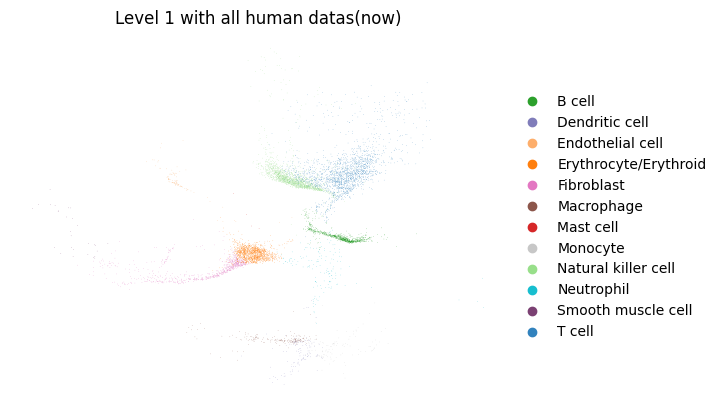

In [8]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_new,
    color='cell_type_level1_human',
    palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


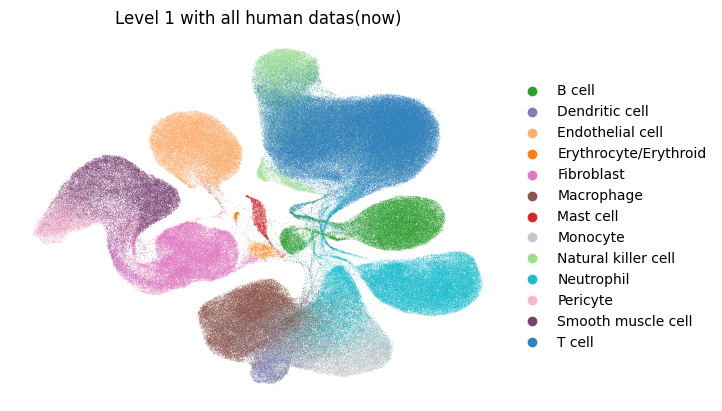

In [9]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_query,
    color='cell_type_level1_human',
    palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

In [10]:
adata_query.obs['cell_types'].value_counts()

cell_types
Mal           2018
T_CD8         1759
T_CD4          856
B_cell         818
T_cell         706
Macrophage     420
?              307
CAF            106
Endo_          104
NK              92
Name: count, dtype: int64

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


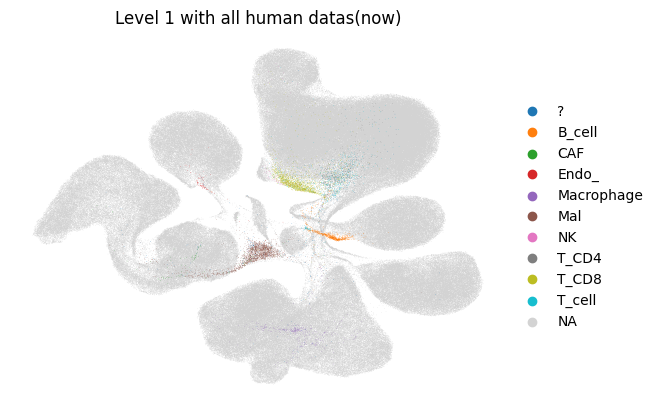

In [11]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_query,
    color='cell_types',
    # palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

# verify

In [12]:
adata_query

AnnData object with n_obs × n_vars = 478666 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'cell_types', 'treatment_group', 'Cohort', 'no_of_genes', 'no_of_reads', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    uns: 'neighbors', 'umap', 'cell_type_level1_human_colors', 'cell_types_colors'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

当前 AnnData 中共有 478666 个细胞
去除指定细胞类型后共有 478666 个细胞
参考 AnnData 中共有 7186 个细胞
共同匹配到 6879 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B_cell', 'Endo_', 'Mal', 'CAF', 'Macrophage', 'NK', 'T_CD8', 'T_CD4', 'T_cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.0254
Weighted precision: 0.0607
Weighted recall: 0.0254

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100.]


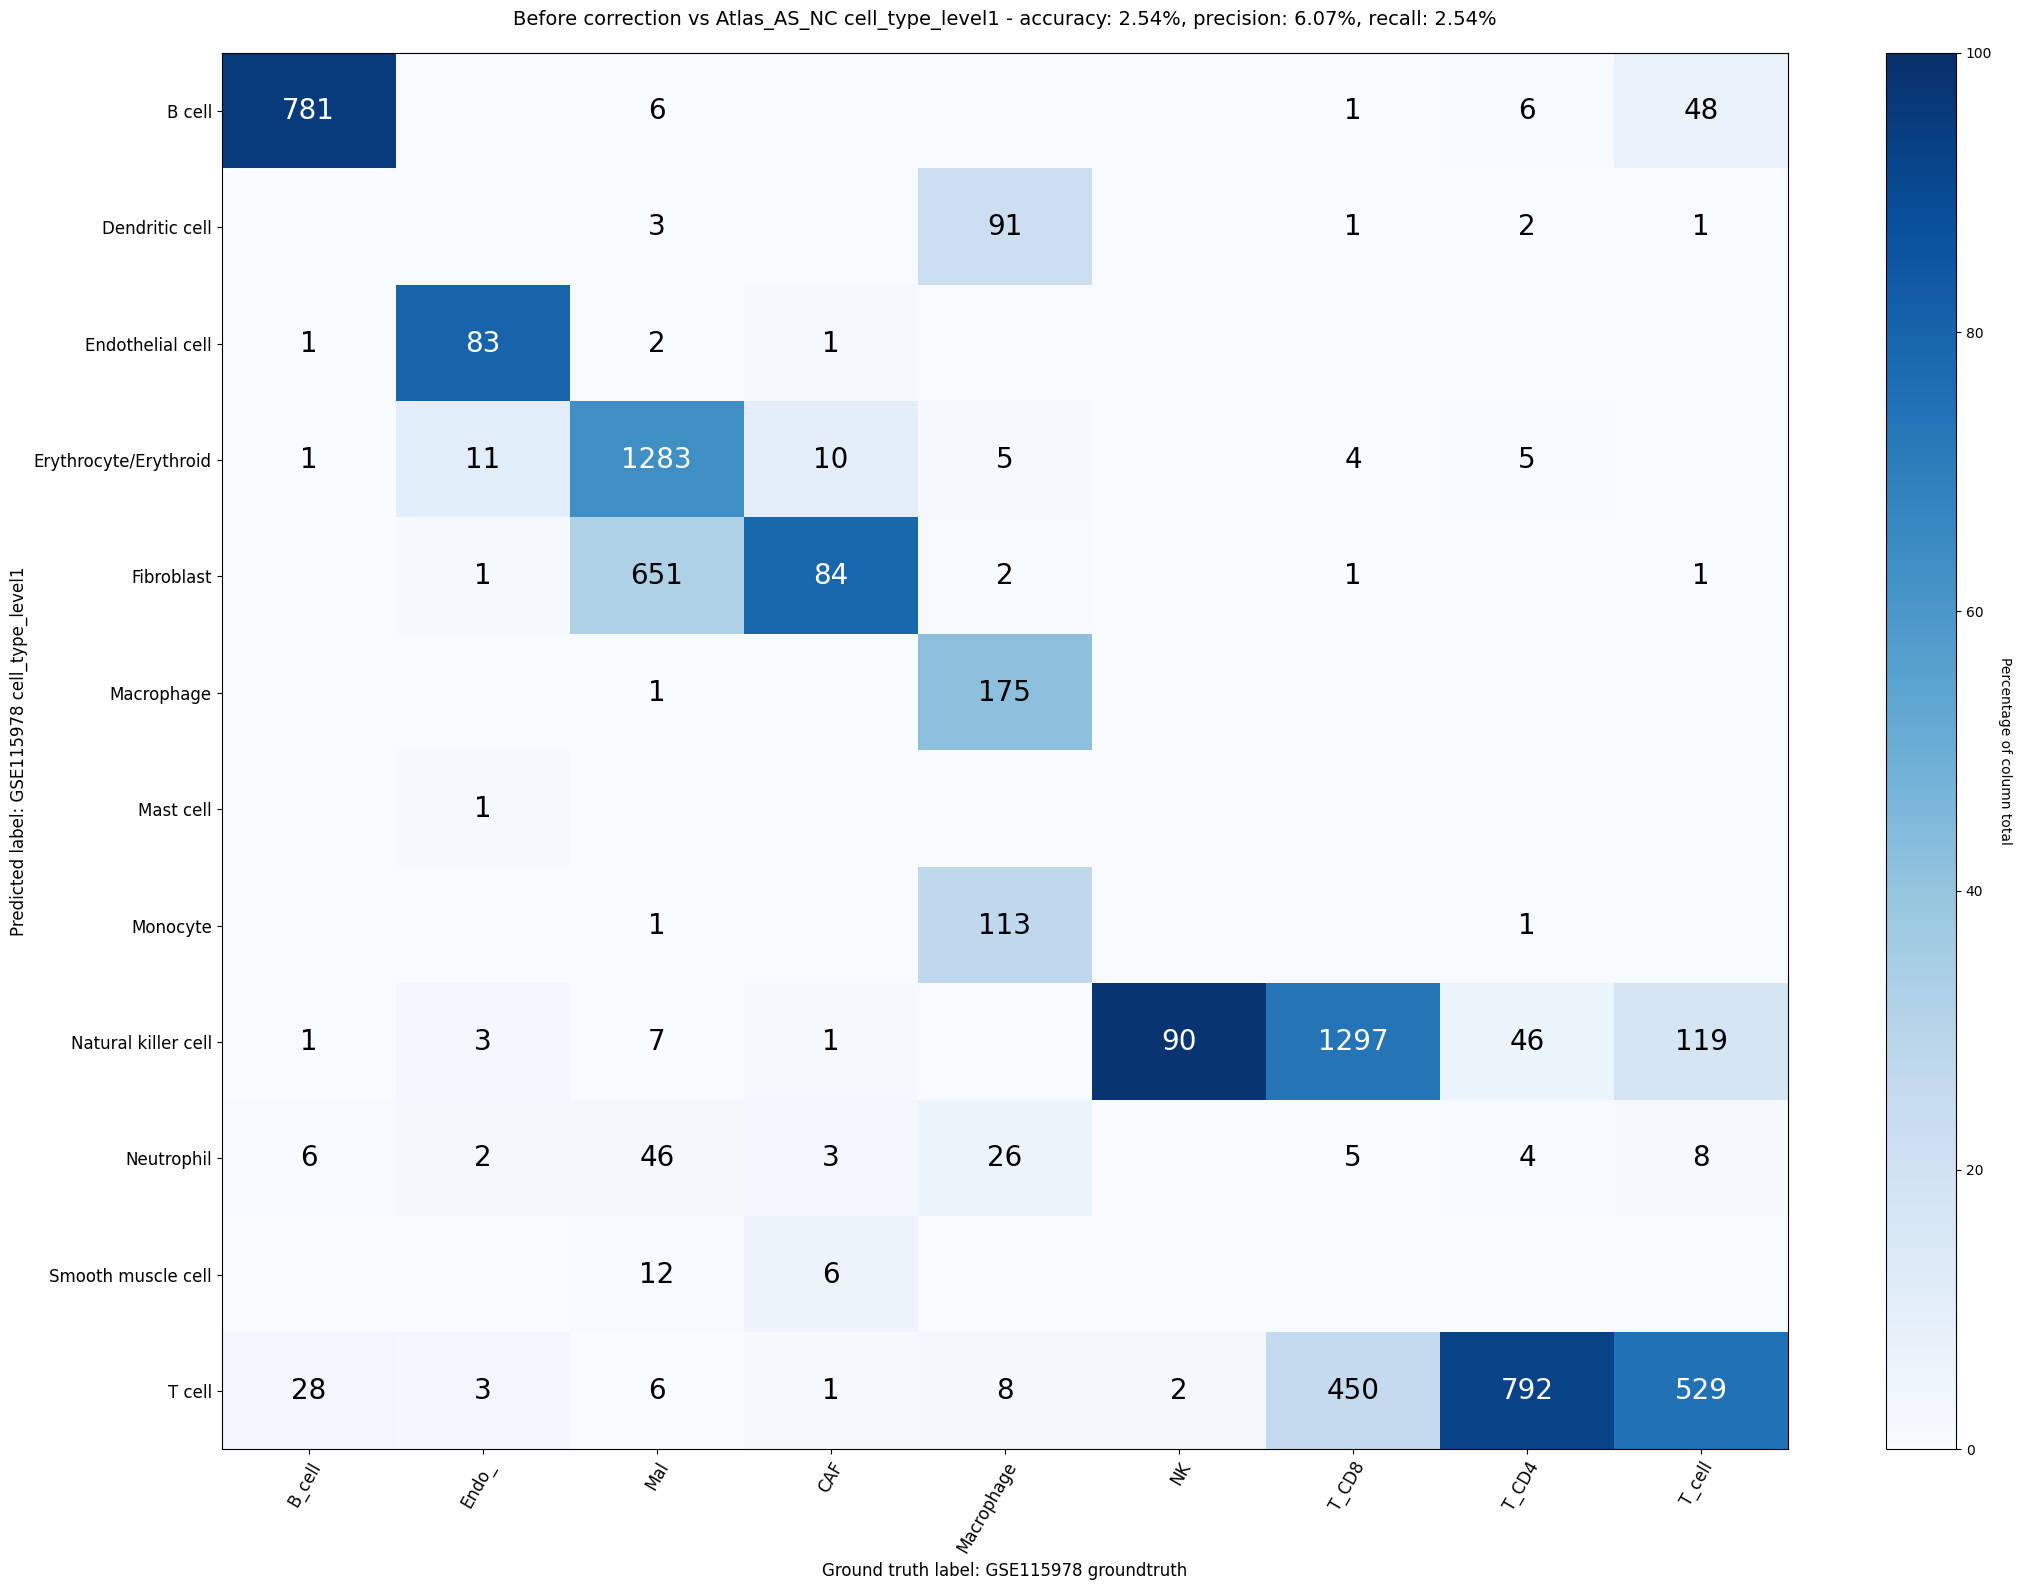


Per-predicted-cell-type precision:
                cell_type  precision
0                  B cell   0.000000
1          Dendritic cell   0.000000
2        Endothelial cell   0.000000
3   Erythrocyte/Erythroid   0.000000
4              Fibroblast   0.000000
5              Macrophage   0.994318
6               Mast cell   0.000000
7                Monocyte   0.000000
8     Natural killer cell   0.000000
9              Neutrophil   0.000000
10     Smooth muscle cell   0.000000
11                 T cell   0.000000

Per-ground-truth-cell-type recall:
    cell_type    recall
0      B_cell  0.000000
1       Endo_  0.000000
2         Mal  0.000000
3         CAF  0.000000
4  Macrophage  0.416667
5          NK  0.000000
6       T_CD8  0.000000
7       T_CD4  0.000000
8      T_cell  0.000000


In [20]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors

# remove_cell_types=["Pericyte","Erythrocyte/Erythroid"]
# adata_query.obs_names = adata_query.obs_names.astype(str)
# adata_query = adata_query[adata_query.obs['atlas_key'] == 'query']
adata_new.obs_names_make_unique()
adata_query.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_new.n_obs

obs_before=adata_query.obs[["cell_type_level1_human"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_new.obs[["cell_types"]].copy()
obs_ref.index=adata_new.obs_names.copy()

adata_query.file.close()

# obs_before = obs_before[
#     ~obs_before["cell_type_level1_human"].isin(remove_cell_types)
# ]
# 去掉 adata_new 中 ground truth 为 ? 的细胞
obs_ref = obs_ref[
    obs_ref["cell_types"].astype(str) != "?"
]
common_indices = obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_human"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_types"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values
x_order = [
    "B_cell",
    "Endo_",
    "Mal",
    "CAF",
    "Macrophage",
    "NK",
    "T_CD8",
    "T_CD4",
    "T_cell"
]
gt_cell_types = [ct for ct in x_order if ct in compare_df["gt"].unique()]
extra_gt_cell_types = [
    ct for ct in sorted(compare_df["gt"].unique())
    if ct not in gt_cell_types
]
gt_cell_types = gt_cell_types + extra_gt_cell_types
pred_cell_types = sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                str(conf_matrix[i,j]),
                # f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: GSE115978 groundtruth",fontsize=12)
ax.set_ylabel("Predicted label: GSE115978 cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

Mal           2018
T_CD8         1759
T_CD4          856
B_cell         818
T_cell         706
Macrophage     420
?              307
CAF            106
Endo_          104
NK              92

B_cell；Endo_；Mal；CAF；Macrophage；NK；T_CD8；T_CD4；T_cell

当前 AnnData 中共有 478666 个细胞
去除指定细胞类型后共有 338208 个细胞
参考 AnnData 中共有 7186 个细胞
共同匹配到 5228 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B_cell', 'Endo_', 'Mal', 'CAF', 'Macrophage', 'NK', 'T_CD8', 'T_CD4', 'T_cell']

Predicted cell types from current adata:
['B cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Natural killer cell', 'T cell']

Accuracy: 0.0335
Weighted precision: 0.0352
Weighted recall: 0.0335

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100.]


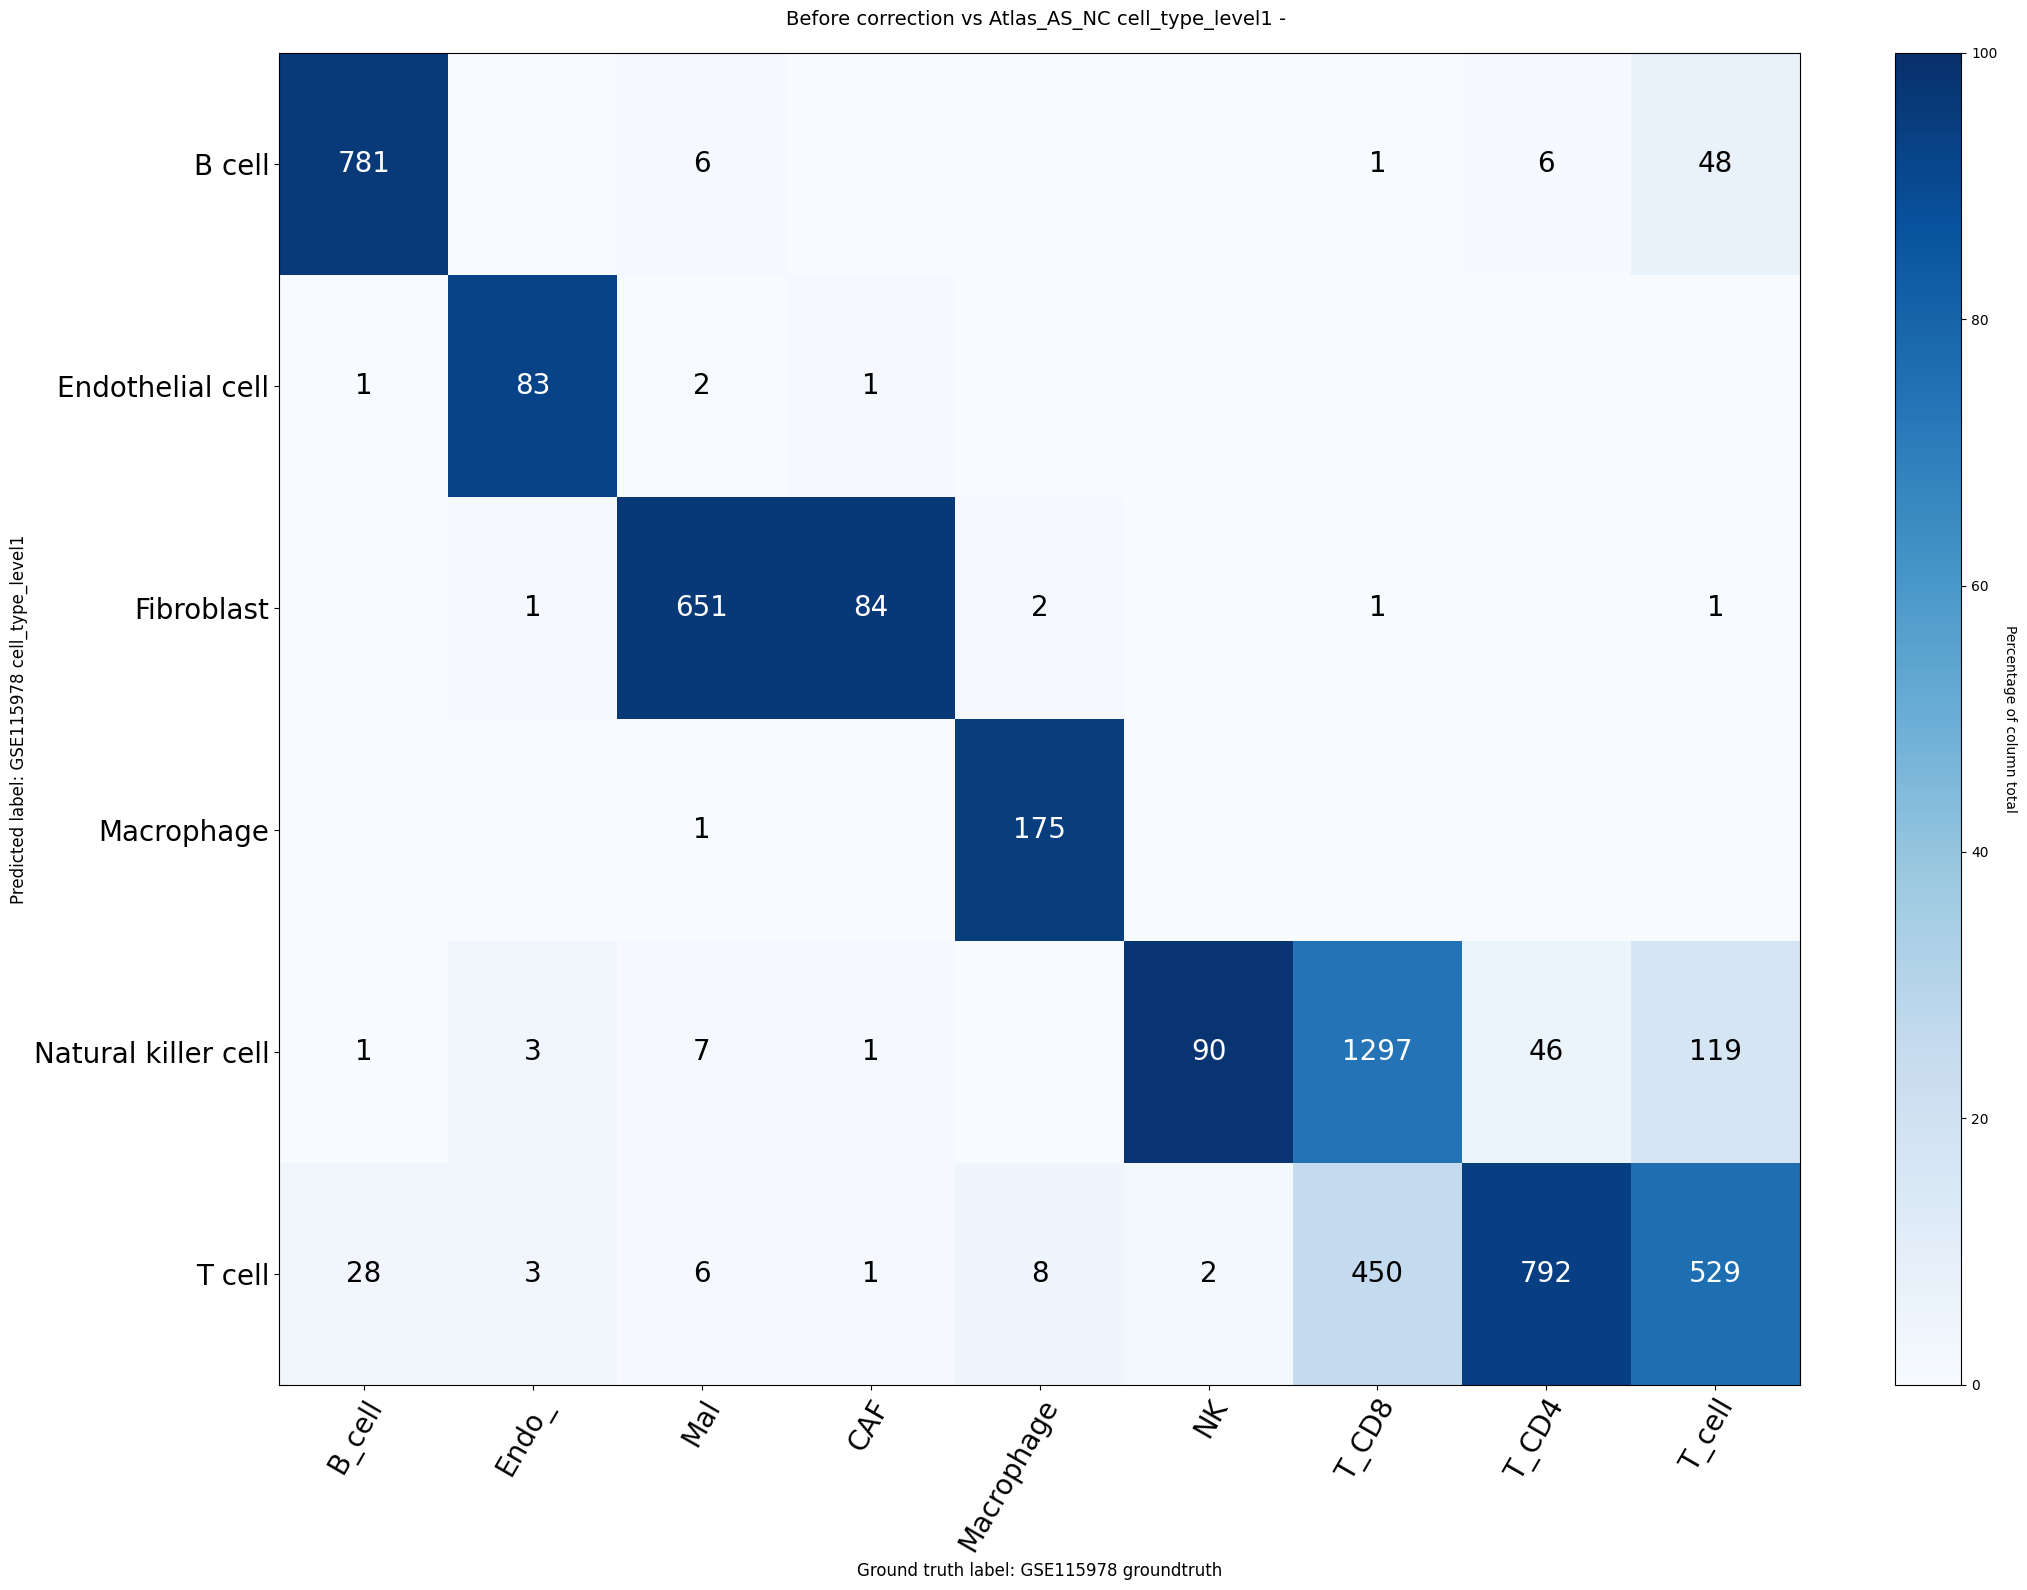


Per-predicted-cell-type precision:
             cell_type  precision
0               B cell   0.000000
1     Endothelial cell   0.000000
2           Fibroblast   0.000000
3           Macrophage   0.994318
4  Natural killer cell   0.000000
5               T cell   0.000000

Per-ground-truth-cell-type recall:
    cell_type    recall
0      B_cell  0.000000
1       Endo_  0.000000
2         Mal  0.000000
3         CAF  0.000000
4  Macrophage  0.945946
5          NK  0.000000
6       T_CD8  0.000000
7       T_CD4  0.000000
8      T_cell  0.000000


In [26]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors
##保留共有细胞类型
remove_cell_types=["Pericyte","Erythrocyte/Erythroid","Dendritic cell","Mast cell","Monocyte","Neutrophil","Smooth muscle cell"]
# adata_query.obs_names = adata_query.obs_names.astype(str)
# adata_query = adata_query[adata_query.obs['atlas_key'] == 'query']
adata_new.obs_names_make_unique()
adata_query.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_new.n_obs

obs_before=adata_query.obs[["cell_type_level1_human"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_new.obs[["cell_types"]].copy()
obs_ref.index=adata_new.obs_names.copy()

adata_query.file.close()

obs_before = obs_before[
    ~obs_before["cell_type_level1_human"].isin(remove_cell_types)
]
# 去掉 adata_new 中 ground truth 为 ? 的细胞
obs_ref = obs_ref[
    obs_ref["cell_types"].astype(str) != "?"
]
common_indices = obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_human"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_types"].astype(str)
})
mapped_cell_types = compare_df["gt"].values
cell_types_pred = compare_df["pred"].values

x_order = ["B_cell", "Endo_", "Mal", "CAF", "Macrophage", "NK", "T_CD8", "T_CD4", "T_cell"]
y_order = ["B cell", "Endothelial cell", "Fibroblast", "Macrophage", "Natural killer cell", "T cell"]

gt_cell_types = [ct for ct in x_order if ct in compare_df["gt"].unique()]
extra_gt_cell_types = [ct for ct in sorted(compare_df["gt"].unique()) if ct not in gt_cell_types]
gt_cell_types = gt_cell_types + extra_gt_cell_types

pred_cell_types = [ct for ct in y_order if ct in compare_df["pred"].unique()]
extra_pred_cell_types = [ct for ct in sorted(compare_df["pred"].unique()) if ct not in pred_cell_types]
pred_cell_types = pred_cell_types + extra_pred_cell_types

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        # f"accuracy: {accuracy:.2%}, "
        # f"precision: {overall_precision:.2%}, "
        # f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=20)
plt.setp(ax.get_yticklabels(),fontsize=20)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                str(conf_matrix[i,j]),
                # f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: GSE115978 groundtruth",fontsize=12)
ax.set_ylabel("Predicted label: GSE115978 cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)